In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import train_test_split

sys.path.append(str((Path.cwd() / '..').resolve()))

from features.schema import FEATURE_NAMES
from ml.dataset import load_event_dataset
from ml.training import train_model_from_event_dirs
from ml.trainers import TrainingConfig

/home/divan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [22]:
DATA_DIR = (Path.cwd() / '..' / 'data' / 'train').resolve()

baseline_cfg = TrainingConfig(model_type='logistic_regression', val_ratio=0.2, seed=42, iterations=300, l2=1e-5)
prod_cfg = TrainingConfig(model_type='random_forest', val_ratio=0.2, seed=42, random_forest_trees=300, random_forest_max_depth=5)

baseline = train_model_from_event_dirs(DATA_DIR, config=baseline_cfg)
production = train_model_from_event_dirs(DATA_DIR, config=prod_cfg)

baseline.val_metrics, production.val_metrics

({'log_loss': 0.29793355231923296,
  'brier_score': 0.10674462546606892,
  'accuracy': 0.875,
  'precision': 0.7777777777777778,
  'recall': 1.0,
  'f1': 0.875,
  'false_positive_rate': 0.2222222222222222,
  'threshold': 0.6,
  'tp': 7,
  'tn': 7,
  'fp': 2,
  'fn': 0,
  'roc_auc': 0.9365079365079365},
 {'log_loss': 0.3716945253368988,
  'brier_score': 0.11973999192314239,
  'accuracy': 0.8125,
  'precision': 0.7,
  'recall': 1.0,
  'f1': 0.8235294117647058,
  'false_positive_rate': 0.3333333333333333,
  'threshold': 0.6,
  'tp': 7,
  'tn': 6,
  'fp': 3,
  'fn': 0,
  'roc_auc': 0.9047619047619049})

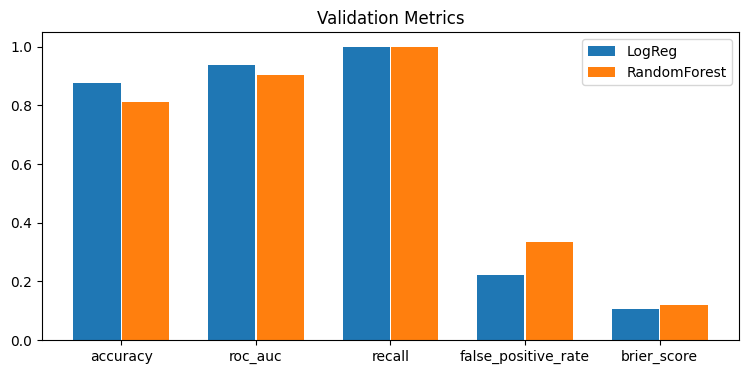

In [27]:
metric_names = [
    'accuracy',
    'roc_auc',
    'recall',
    'false_positive_rate',
    'brier_score',
]
baseline_vals = [baseline.val_metrics.get(name) or 0.0 for name in metric_names]
prod_vals = [production.val_metrics.get(name) or 0.0 for name in metric_names]

x = range(len(metric_names))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar([i - 0.18 for i in x], baseline_vals, width=0.35, label='LogReg')
ax.bar([i + 0.18 for i in x], prod_vals, width=0.35, label='RandomForest')
ax.set_ylim(0, 1.05)
ax.set_xticks(list(x))
ax.set_xticklabels(metric_names)
ax.set_title('Validation Metrics')
ax.legend()
plt.show()

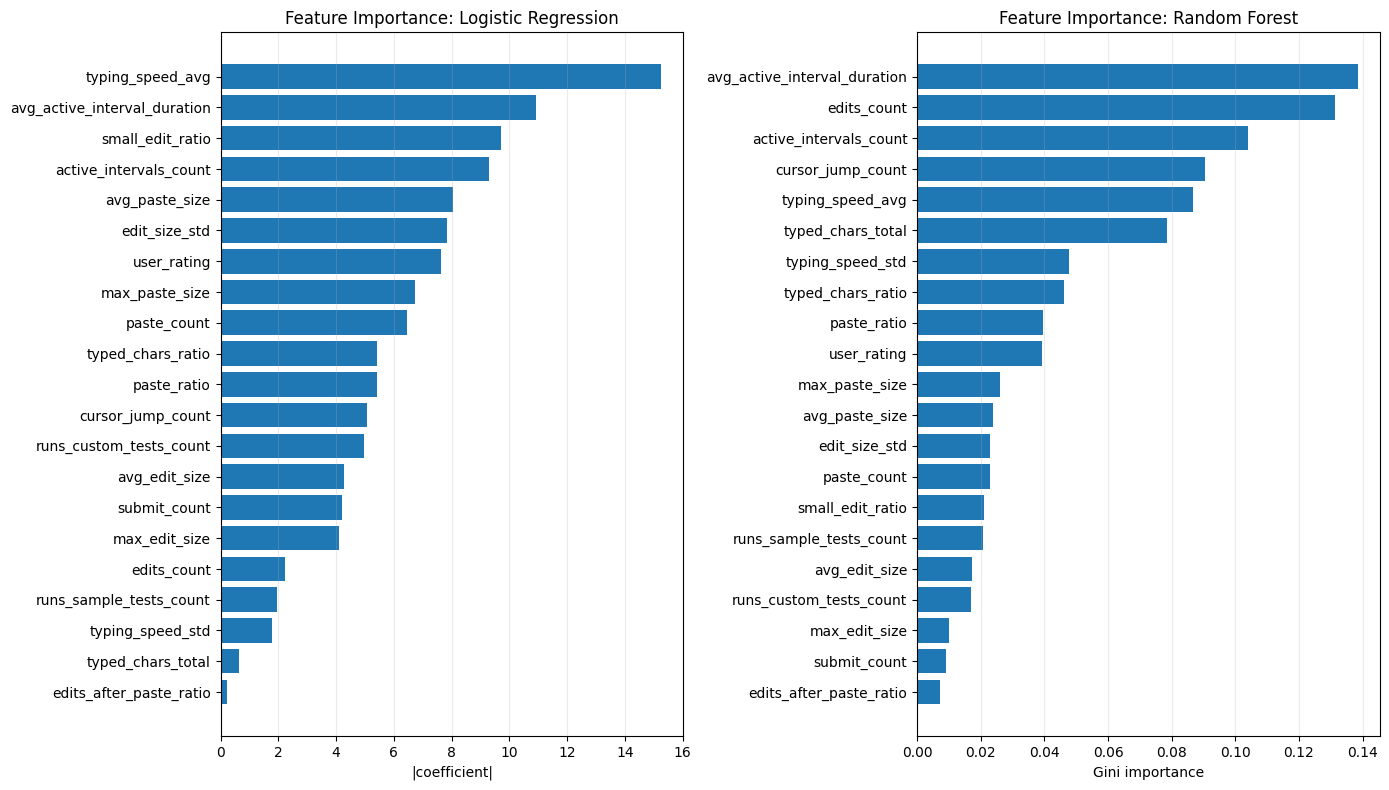

,feature,importance
3,avg_active_interval_duration,0.138534
4,edits_count,0.131184
2,active_intervals_count,0.103916
14,cursor_jump_count,0.090439
0,typing_speed_avg,0.086550
16,typed_chars_total,0.078463
1,typing_speed_std,0.047756
15,typed_chars_ratio,0.046224
12,paste_ratio,0.039454
20,user_rating,0.039296


In [28]:
baseline_estimator = baseline.model.named_steps['logisticregression']
production_estimator = production.model.named_steps['randomforestclassifier']

baseline_importance = pd.DataFrame({
    'feature': FEATURE_NAMES,
    'importance': abs(baseline_estimator.coef_[0]),
}).sort_values('importance', ascending=True)

production_importance = pd.DataFrame({
    'feature': FEATURE_NAMES,
    'importance': production_estimator.feature_importances_,
}).sort_values('importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=False)

axes[0].barh(baseline_importance['feature'], baseline_importance['importance'])
axes[0].set_title('Feature Importance: Logistic Regression')
axes[0].set_xlabel('|coefficient|')

axes[1].barh(production_importance['feature'], production_importance['importance'])
axes[1].set_title('Feature Importance: Random Forest')
axes[1].set_xlabel('Gini importance')

for ax in axes:
    ax.grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.show()

display(production_importance.sort_values('importance', ascending=False).head(10))

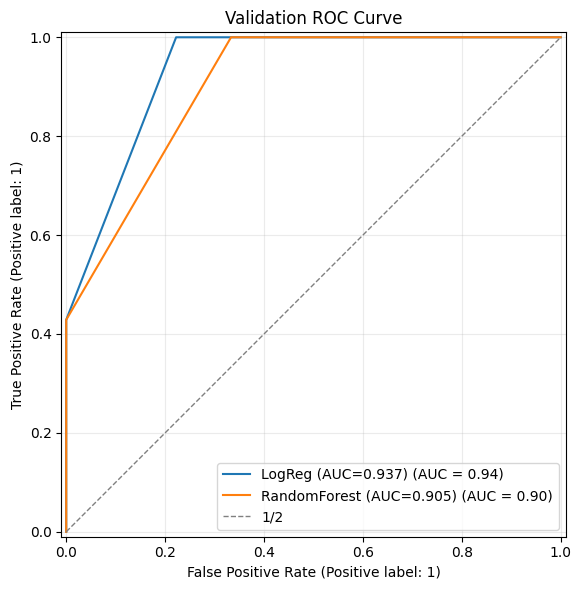

In [29]:
x_all, y_all = load_event_dataset(DATA_DIR)
_, x_val, _, y_val = train_test_split(
    x_all,
    y_all,
    test_size=prod_cfg.val_ratio,
    random_state=prod_cfg.seed,
    stratify=y_all,
)

baseline_val_proba = baseline.model.predict_proba(x_val)[:, 1]
production_val_proba = production.model.predict_proba(x_val)[:, 1]

fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(
    y_val,
    baseline_val_proba,
    name=f"LogReg (AUC={baseline.val_metrics['roc_auc']:.3f})",
    ax=ax,
)
RocCurveDisplay.from_predictions(
    y_val,
    production_val_proba,
    name=f"RandomForest (AUC={production.val_metrics['roc_auc']:.3f})",
    ax=ax,
)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='1/2')
ax.set_title('Validation ROC Curve')
ax.grid(alpha=0.25)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()